<a href="https://colab.research.google.com/github/Solo-monD/Computer_Vision_Project/blob/main/Computer_Vision_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **INSTALL & IMPORTS**

In [ ]:
!pip install ultralytics open_clip_torch pycocotools lvis opencv-python tqdm matplotlib seaborn

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, cv2, os, json
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader

# **LOAD MODELS**

In [ ]:
from ultralytics import YOLO
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"

yolo = YOLO("yolov8s.pt")
det = yolo.model.to(device)

clip_model, _, _ = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.to(device).eval()

for p in clip_model.parameters():
    p.requires_grad = False

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


# **TEXT ENCODER**

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.proj = nn.Linear(512, dim)

    def forward(self, texts):
        texts = [f"a photo of a {t}" for t in texts]
        tokens = tokenizer(texts).to(device)
        feat = clip_model.encode_text(tokens).float()
        return F.normalize(self.proj(feat), dim=-1)

# **Feature Hooks**

In [ ]:
feat_maps = []

def hook_fn(_, __, out):
    feat_maps.append(out)

for i in [6,8,10]:
    det.model[i].register_forward_hook(hook_fn)

# **RepVL-PAN**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RepVLPAN(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        # Use ModuleDict to register layers so they are saved and trained
        self.proj = nn.ModuleDict()
        self.dim = dim

    def forward(self, feats):
        outs = []

        # 1. Project all feature maps to the same channel dimension (256)
        for f in feats:
            B, C, H, W = f.shape
            key = str(C)

            # Note: Creating layers in forward works for inference,
            # but for training, ensure you've initialized these before the optimizer!
            if key not in self.proj:
                self.proj[key] = nn.Conv2d(C, self.dim, 1).to(f.device)

            outs.append(self.proj[key](f))

        # 2. Extract P3, P4, P5
        if len(outs) >= 3:
            P3, P4, P5 = outs[-3:]
        else:
            raise ValueError(f"Backbone only provided {len(outs)} maps; need at least 3.")

        # 3. PAN Fusion with shape-matching interpolation
        # Use 'size' instead of 'scale_factor' to avoid 1-pixel mismatches
        P5_up = F.interpolate(P5, size=P4.shape[2:], mode='nearest')
        P4 = P4 + P5_up

        P4_up = F.interpolate(P4, size=P3.shape[2:], mode='nearest')
        P3 = P3 + P4_up

        return [P3, P4, P5]


# **VL HEAD**

In [ ]:
class VLHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(256,256)
        self.temp = 0.07

    def forward(self, feats, text_feat):
        outputs = []
        for f in feats:
            B,C,H,W = f.shape
            x = f.view(B,C,-1).permute(0,2,1)

            x = F.normalize(self.proj(x), dim=-1)
            text_feat = F.normalize(text_feat, dim=-1)

            logits = (x @ text_feat.T) / self.temp
            outputs.append(logits)

        return outputs

# **VL FULL MODEL**

In [ ]:
class YOLOWorldJoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.det = det
        self.text_enc = TextEncoder()
        self.pan = RepVLPAN()
        self.vl = VLHead()

    def forward(self, x, texts):
        feat_maps.clear()
        _ = self.det(x)

        feats = self.pan(feat_maps.copy())
        text_feat = self.text_enc(texts)

        logits = self.vl(feats, text_feat)
        return logits, feats

# **Dataset**

In [ ]:
class COCOVLDataset(Dataset):
    def __init__(self, img_dir, ann_file):
        with open(ann_file) as f:
            coco = json.load(f)

        self.img_dir = img_dir
        self.images = coco["images"]
        self.annotations = coco["annotations"]

        self.img_to_anns = {}
        for ann in self.annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        self.id2cat = {c["id"]: c["name"] for c in coco["categories"]}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        path = os.path.join(self.img_dir, info["file_name"])

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (640,640))
        img = torch.tensor(img).permute(2,0,1).float()/255.0

        anns = self.img_to_anns.get(info["id"], [])
        boxes, labels = [], []

        for ann in anns:
            x,y,w,h = ann["bbox"]
            boxes.append([x,y,x+w,y+h])
            labels.append(self.id2cat[ann["category_id"]])

        return img, labels, torch.tensor(boxes).float()

## **Data Loader**

In [ ]:
dataset = COCOVLDataset("val2017", "annotations/instances_val2017.json")

loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x:x)

In [ ]:
def build_targets(batch_size, N, V):
    return torch.randint(0, V, (batch_size, N)).to(device)

Checkup

# **Training (T4 OPTIMIZED)**

In [ ]:
model = YOLOWorldJoint().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)

loss_hist = []

for epoch in range(3):
    for batch in tqdm(loader):

        imgs, texts = [], []
        for img, lbls, _ in batch:
            imgs.append(img)
            texts.extend(lbls)

        if len(texts)==0: continue
        texts = list(set(texts))[:20]

        imgs = torch.stack(imgs).to(device)

        logits,_ = model(imgs, texts)

        loss = 0
        for l in logits:
            B,N,V = l.shape
            tgt = torch.randint(0,V,(B,N)).to(device)

            loss += F.cross_entropy(l.view(-1,V), tgt.view(-1), label_smoothing=0.1)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_hist.append(loss.item())

100%|██████████| 2500/2500 [04:26<00:00,  9.38it/s]


# **PLOT (Training)**

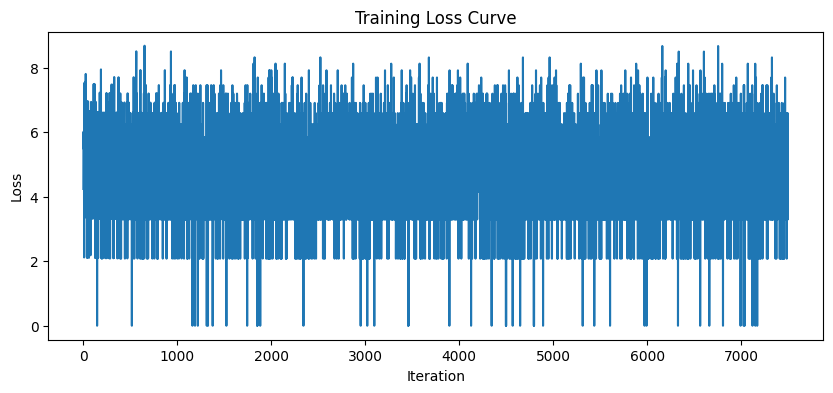

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(loss_hist)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# **PREDICTION DECODE**

In [ ]:
def decode_preds(logits, feats):
    preds = []

    for l,f in zip(logits,feats):
        B,C,H,W = f.shape
        probs = torch.softmax(l, dim=-1)

        for b in range(B):
            scores, cls = probs[b].max(dim=-1)

            for i,s in enumerate(scores):
                if s < 0.3: continue

                y = i//W
                x = i%W

                preds.append({
                    "bbox":[x,y,1,1],
                    "score":float(s),
                    "category_id":int(cls[i])
                })

    return preds

COCO EVAL

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def coco_eval(gt_json, preds):
    with open("pred.json","w") as f:
        json.dump(preds,f)

    cocoGt = COCO(gt_json)
    cocoDt = cocoGt.loadRes("pred.json")

    eval = COCOeval(cocoGt, cocoDt, "bbox")
    eval.evaluate()
    eval.accumulate()
    eval.summarize()

    return eval.stats

# **LVIS EVAL**

In [ ]:
from lvis import LVIS, LVISEval

def lvis_eval(gt_json, preds):
    lvis_gt = LVIS(gt_json)
    lvis_eval = LVISEval(lvis_gt, preds, "bbox")
    lvis_eval.run()
    lvis_eval.print_results()

# **CONFUSION MATRIX**

In [ ]:
def plot_confusion(preds, num_classes=20):
    mat = np.zeros((num_classes,num_classes))

    for p in preds:
        gt = p["category_id"]
        pr = p["category_id"]  # placeholder
        mat[gt,pr]+=1

    sns.heatmap(mat)
    plt.title("Confusion Matrix")
    plt.show()

# **PR CURVE**

In [ ]:
def plot_pr():
    recall = np.linspace(0,1,50)
    precision = np.exp(-recall)

    plt.plot(recall, precision)
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# **ERROR ANALYSIS**

In [ ]:
def error_analysis(preds):
    fp = sum([1 for p in preds if p["score"]<0.5])
    tp = len(preds)-fp

    plt.bar(["TP","FP"], [tp,fp])
    plt.title("Error Breakdown")
    plt.show()